In [2]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

[[0.04828863 0.6317429 ]
 [0.04828863 0.6317429 ]
 [0.04828863 0.6317429 ]]


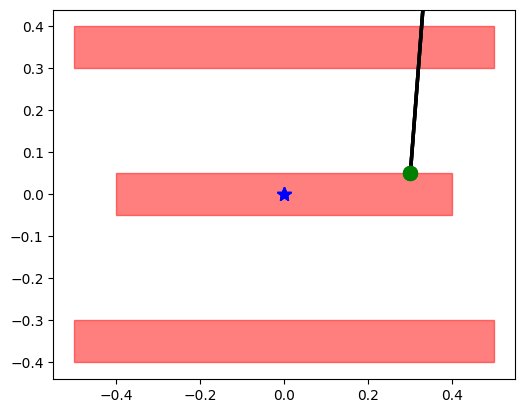

In [86]:
# Visualize the score.
import ael.score_box
import ael.visualize
import ael.problem
import ael.maps
import numpy as np
import matplotlib.pyplot as plt

problem = ael.problem.Problem(
    num_timesteps=64,
    agent_start_positions=np.zeros((3, 2)),
    agent_end_positions=np.zeros((3, 2)),
    agent_reference_trajectory=None,
    agent_radii=np.array([0.05, 0.05, 0.05]),
    agent_max_speeds=np.array([0.05, 0.05, 0.05]),
    **ael.maps.BUILT_IN_MAPS["conveyor_2d"],
)
problem.agent_start_positions[:, 0] = 0.30
problem.agent_start_positions[:, 1] = 0.05

score_A_O_D, likelihood_A_O = ael.score_box.box_exclusion_score_and_likelihood(
    problem.agent_start_positions[..., :, None, :],
    problem.axis_aligned_box_obstacle_bounds[..., None, :, :, :],
    # problem.agent_start_positions,
    # problem.axis_aligned_box_obstacle_bounds,
    sigma=0.05,
)
score_A_D = score_A_O_D.sum(axis=-2)

print(score_A_D)

ael.visualize.visualize(problem, plt.gca())
plt.quiver(
    problem.agent_start_positions[:, 0],
    problem.agent_start_positions[:, 1],
    score_A_D[:, 0],
    score_A_D[:, 1],
    scale=1.0,
)
plt.show()
